In [1]:
from ultralytics import YOLO
import numpy as np
import torch
import cv2

In [2]:
# Detector
yolo = YOLO('yolov8n.pt') 

In [3]:
# Encoder
encoder = torch.hub.load('pytorch/vision:v0.10.0', 'resnet18', pretrained=True)
encoder = torch.nn.Sequential(*list(encoder.children())[:-1])  # remove classifier
encoder.eval()

Downloading: "https://github.com/pytorch/vision/zipball/v0.10.0" to C:\Users\sahar/.cache\torch\hub\v0.10.0.zip


c:\Users\sahar\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\sahar\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\sahar/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 48.7MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Con

In [4]:
def preprocess_image(img):
    img = cv2.resize(img, (224, 224))
    img = img / 255.0  # normalize to [0, 1]
    img = np.transpose(img, (2, 0, 1))  # HWC to CHW
    return torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # add batch dimension

def encode(img):
    with torch.no_grad():
        x = preprocess_image(img)
        features = encoder(x).squeeze().numpy()  # remove batch dimension
    return features / np.linalg.norm(features)  # L2 normalize

In [12]:
reference_images = [
    'coke-can.png'
]
ref_embeddings = []

In [19]:
for path in reference_images:
    img = cv2.imread(path)
    embedding = encode(img)
    ref_embeddings.append(embedding)

In [14]:
prototype = np.mean(ref_embeddings, axis=0)
prototype = prototype / np.linalg.norm(prototype)  # L2 normalize

c:\Users\sahar\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\sahar\anaconda3\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [20]:
# scene image is what we want to analyze
scene = cv2.imread('./coke-cans.jpg')
results = yolo(scene)[0]  # get first (and only) result


0: 448x640 1 cup, 136.6ms
Speed: 3.7ms preprocess, 136.6ms inference, 6.4ms postprocess per image at shape (1, 3, 448, 640)


In [16]:
count = 0
threshold = 0.8  # cosine similarity threshold

In [22]:
for box in results.boxes.xyxy:
    x1, y1, x2, y2 = map(int, box.tolist())

    crop = scene[y1:y2, x1:x2]

    if crop.size == 0:
        continue

    emb = encode(crop)

    # cosine similarity
    sim = np.dot(emb, prototype)

    # make sim a scalar and handle NaN values safely
    if isinstance(sim, np.ndarray):
        sim = float(np.nanmean(sim))
    sim = float(np.nan_to_num(sim, nan=-1.0))

    if sim > threshold:
        count += 1

        # draw box
        cv2.rectangle(scene, (x1, y1), (x2, y2), (0,255,0), 2)
        cv2.putText(scene, f"{sim:.2f}", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)

C:\Users\sahar\AppData\Local\Temp\ipykernel_28216\2145797872.py:16: RuntimeWarning: Mean of empty slice
  sim = float(np.nanmean(sim))


COUNT = 0


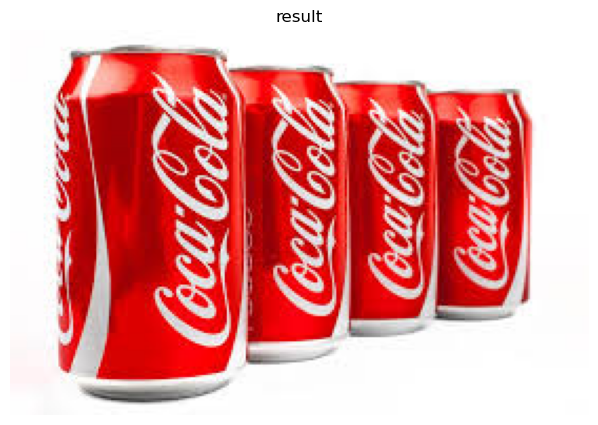

In [25]:
import matplotlib.pyplot as plt

print("COUNT =", count)

# show result inline in notebook (no GUI window required)
scene_rgb = cv2.cvtColor(scene, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 5))
plt.imshow(scene_rgb)
plt.title("result")
plt.axis("off")
plt.show()